In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [5]:
def normal_autocorr(mu, sigma, tau, N):
    """Generates an autocorrelated sequence of Gaussian random numbers.
    
    Each of the random numbers in the sequence of length `N` is distributed
    according to a Gaussian with mean `mu` and standard deviation `sigma` (just
    as in `numpy.random.normal`, with `loc=mu` and `scale=sigma`). Subsequent
    random numbers are correlated such that the autocorrelation function
    is on average `exp(-n/tau)` where `n` is the distance between random
    numbers in the sequence.
    
    This function implements the algorithm described in
    https://www.cmu.edu/biolphys/deserno/pdf/corr_gaussian_random.pdf
    
    Parameters
    ----------
    
    mu: float
        mean of each Gaussian random number
    sigma: float
        standard deviation of each Gaussian random number
    tau: float
        autocorrelation time
    N: int
        number of desired random numbers
    
    Returns:
    --------
    sequence: numpy array
        array of autocorrelated random numbers
    """
    f = np.exp(-1./tau)
    
    sequence = np.zeros(shape=(N,))
    
    sequence[0] = np.random.normal(0, 1)
    for i in range(1, N):
        sequence[i] = f * sequence[i-1] + np.sqrt(1 - f**2) * np.random.normal(0, 1)
    
    return mu + sigma * sequence

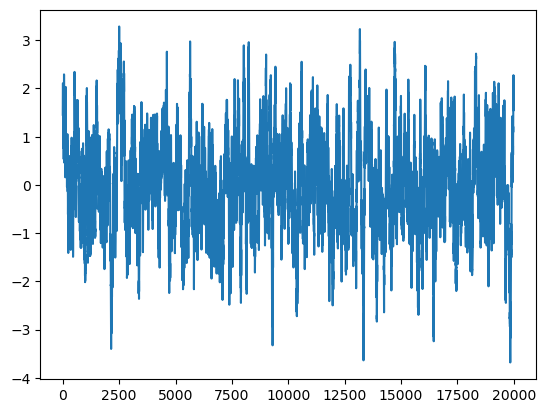

In [25]:
data = normal_autocorr(0, 1, 50, 20000)
plt.plot(data)
plt.show()

In [26]:
def data_blocking(A, max_block_size=None):
    N = len(A)
    if max_block_size is None:
        max_block_size = N // 10  # Default max block size to N/10

    block_sizes = np.arange(1, max_block_size + 1)
    errors = []

    for b in block_sizes:
        Nb = N // b  # Number of blocks
        block_averages = np.array([np.mean(A[i * b:(i + 1) * b]) for i in range(Nb)])
        
        sigma_A_b = np.std(block_averages, ddof=0) / np.sqrt(Nb - 1)  # Compute error
        errors.append(sigma_A_b)

    return block_sizes, np.array(errors)


In [27]:
# Example usage
# observables = np.array(kinetic_energy[t_eq:])  # Replace with any observable
block_sizes, errors = data_blocking(data, max_block_size=500)

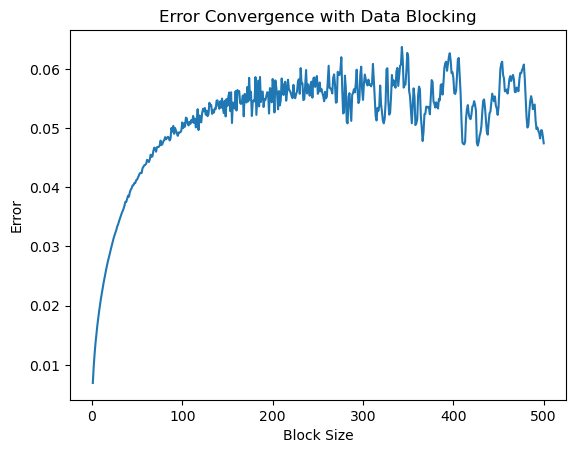

In [28]:
# Plot the error convergence

plt.plot(block_sizes, errors, linestyle='-')
plt.xlabel("Block Size")
plt.ylabel("Error")
plt.title("Error Convergence with Data Blocking")
plt.show()

Final error: 0.05532270978671269


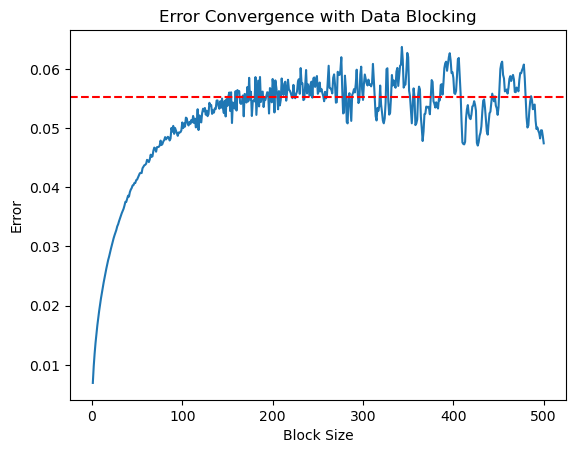

In [31]:
# Plot the error convergence
final_error = np.mean(errors[-len(errors) // 10:])
print(f"Final error: {final_error}")
plt.plot(block_sizes, errors, linestyle='-')
plt.axhline(final_error, color='r', linestyle='--', label=f"Final Error: {final_error:.4f}")
plt.xlabel("Block Size")
plt.ylabel("Error")
plt.title("Error Convergence with Data Blocking")
plt.show()


In [32]:
def autocorrelation(A):
    """Compute the autocorrelation function using the biased estimator."""
    N = len(A)
    A = np.array(A)
    
    A_sum = np.cumsum(A)  
    A_sq_sum = np.cumsum(A**2)  
    count= 0
    autocorr = []
    
    for t in range(1, N-1):  
        num = (N - t) * np.sum(A[:-t] * A[t:]) - A_sum[N - t - 1] * (A_sum[N - 1] - A_sum[t - 1])
        denom1 = (N - t) * A_sq_sum[N - t - 1] - A_sum[N - t - 1] ** 2
        denom2 = (N - t) * (A_sq_sum[N - 1] - A_sq_sum[t - 1]) - (A_sum[N - 1] - A_sum[t - 1]) ** 2
        
        if denom1 <= 0 or denom2 <= 0:
            count += 1
        else:
            autocorr.append(num / np.sqrt(denom1 * denom2))
    print(count)
    return np.array(autocorr)


In [33]:
def exp_decay(t, tau):
    return np.exp(-t / tau)


In [34]:
# Compute autocorrelation function
autocorr_values = autocorrelation(data)

# Fit to exponential decay
time_vals = np.arange(1, len(autocorr_values) + 1)
popt, _ = curve_fit(exp_decay, time_vals, autocorr_values, p0=(10))  # Initial guess for tau=10
tau = popt[0]

# Compute error using tau
sigma_A = np.sqrt(2 * tau / len(data) * np.var(data, ddof=1))


0


Estimated correlation time τ: 38.975
Estimated error using autocorrelation: 0.061


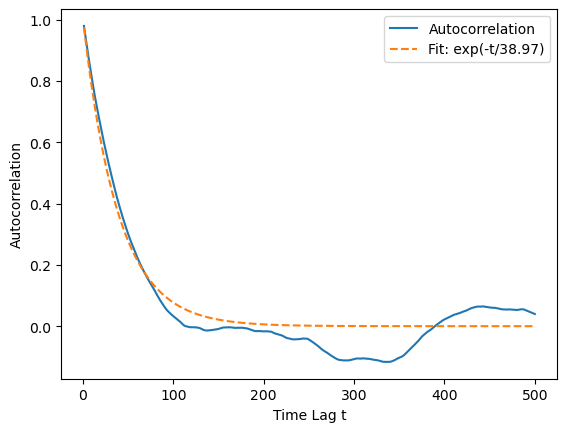

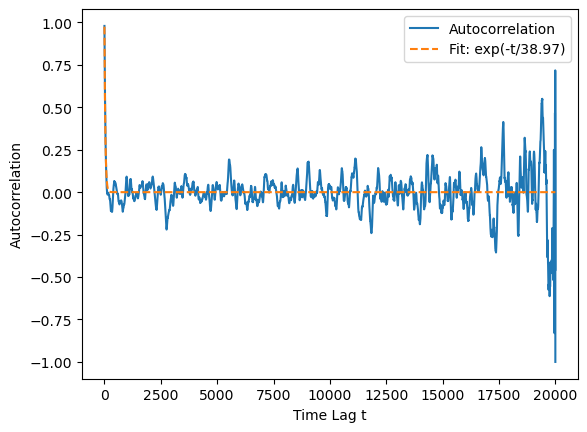

In [35]:
print(f"Estimated correlation time τ: {tau:.3f}")
print(f"Estimated error using autocorrelation: {sigma_A:.3f}")

# Plot autocorrelation function
plt.plot(time_vals[0:500], autocorr_values[0:500], label="Autocorrelation")
plt.plot(time_vals[0:500], exp_decay(time_vals, tau)[0:500], '--', label=f"Fit: exp(-t/{tau:.2f})")
plt.xlabel("Time Lag t")
plt.ylabel("Autocorrelation")
plt.legend()
plt.show()

plt.plot(time_vals, autocorr_values, label="Autocorrelation")
plt.plot(time_vals, exp_decay(time_vals, tau), '--', label=f"Fit: exp(-t/{tau:.2f})")
plt.xlabel("Time Lag t")
plt.ylabel("Autocorrelation")
plt.legend()
plt.show()


In [17]:
test_kinetic_energy = np.random.normal(loc=1.5, scale=0.1, size=10000) 
amount_of_particles = len(test_kinetic_energy)

In [36]:
def bootstrap_specific_heat(kinetic_energy, N, num_samples=1000, block_size=10):
    kinetic_energy = np.array(kinetic_energy)
    num_blocks = len(kinetic_energy) // block_size
    block_averages = np.array([np.mean(
        kinetic_energy[i * block_size: (i + 1) * block_size]) for i in range(num_blocks)])

    bootstrap_values = []

    for _ in range(num_samples):
        resampled_data = np.random.choice(
            block_averages, size=num_blocks, replace=True)
        K_mean = np.mean(resampled_data)
        K_sq_mean = np.mean(resampled_data**2)
        delta_K_sq = K_sq_mean - K_mean**2

        # Compute specific heat
        c_V = 3/(2*(1-(3*amount_of_particles*delta_K_sq)/(2*K_mean**2)))
        bootstrap_values.append(c_V)


    cV_mean = np.mean(bootstrap_values)
    cV_error = np.sqrt(
        np.mean(np.square(bootstrap_values)) - cV_mean**2)

    return cV_mean, cV_error

In [37]:
K_mean = np.mean(test_kinetic_energy)
K_sq_mean = np.mean(test_kinetic_energy**2)
delta_K_sq = K_sq_mean - K_mean**2

# Compute specific heat
c_V = 1/(2/(3*amount_of_particles) -
            (delta_K_sq/(K_mean**2)))
c_V = c_V/amount_of_particles
print(f"Specific heat: {c_V}")

Specific heat: -0.02268956398899736


In [38]:
cV_mean, cV_error = bootstrap_specific_heat(test_kinetic_energy, amount_of_particles)
print(f"Specific heat: {cV_mean} +/- {cV_error}")

Specific heat: -0.27903504916238786 +/- 0.014509178343243438
